In [23]:
import tensorly as tl
from tensorly.metrics import RMSE
import numpy as np
import importlib
import pandas as pd
from skimage.filters import threshold_li, threshold_yen, threshold_otsu
from matplotlib import pyplot as plt
import geopandas as gpd
import contextily as ctx

from app import oslo_lib, CCC

city = 'Oslo'
hex_grid = gpd.read_parquet(f"data/{city}/hex_grid.geoparquet")

OD_matrix = pd.read_pickle(f"data/{city}/cell_OD.pkl")
total_trips_per_year = OD_matrix.groupby(level=0).sum()

OD_matrix = OD_matrix.drop(2025, errors='ignore')

OD_matrix = OD_matrix / total_trips_per_year  
OD_matrix = OD_matrix.groupby(level=(1,2,3,4,5,6)).mean()  # average across all years
OD_matrix = OD_matrix.reset_index()

all_cells = set(OD_matrix.start_cell.unique()).union(set(OD_matrix.end_cell.unique()))

week_OD = OD_matrix.query("weekday<5").drop("weekday", axis=1)
we_OD = OD_matrix.query("weekday>=5").drop("weekday", axis=1)

min_month = 1
max_month = 12
dataset = week_OD

dataset = dataset.query(f"month>={min_month} & month <= {max_month}").groupby(['hour', 'start_cell', 'end_cell']).trip.mean().reset_index()
dataset = dataset.pivot(index=['hour', 'start_cell'], columns='end_cell', values='trip').fillna(0)
dataset = 100 * dataset/dataset.sum().sum()


In [24]:
print(city)
print(len(hex_grid))
print(total_trips_per_year)

Oslo
97
year
2019    2245247
2020    1696054
2021    1419284
2022    1286158
2023     620675
2024    1143379
2025     348276
Name: trip, dtype: int64


In [22]:
print(city)
print(len(hex_grid))
print(total_trips_per_year)

Milan
149
year
2022     144307
2023    1642410
2024    2678512
2025    1336136
Name: trip, dtype: int64


In [20]:
print(city)
print(len(hex_grid))
print(total_trips_per_year)

Edinburgh
251
year
2018     14147
2019    109013
2020    234966
2021     89119
Name: trip, dtype: int64


In [18]:
OD_matrix

,month,weekday,quarter,hour,start_cell,end_cell,trip
0,1,0,0,0,8819723925fffff,8819727611fffff,0.000004
1,1,0,0,0,8819723925fffff,8819727619fffff,0.000004
2,1,0,0,0,8819723925fffff,881972761dfffff,0.000009
3,1,0,0,0,8819727449fffff,8819727603fffff,0.000004
4,1,0,0,0,8819727619fffff,8819723925fffff,0.000004
...,...,...,...,...,...,...,...
250542,12,6,7,23,8819727657fffff,8819727615fffff,0.000004
250543,12,6,7,23,8819727657fffff,8819727657fffff,0.000049
250544,12,6,7,23,881972765bfffff,8819727615fffff,0.000009
250545,12,6,7,23,881972765dfffff,8819720cb3fffff,0.000009


In [4]:
time_slices = [dataset.loc[h] for h in dataset.index.get_level_values(0).unique()]
T = np.array([time_slice.reindex(time_slice.columns).fillna(0) for time_slice in time_slices])
T = tl.tensor(data = T.astype('float64'))

In [5]:
def get_RMSE_error_range(T, 
                         factorization, 
                         reconstruction_function, 
                         rank_range, 
                         nruns=10, 
                         debug=False, 
                         init='svd', 
                        ):
    errors = []
    error_stds = []
    for rank in rank_range:
        print(rank)
        local_errors = []
        for run in range(nruns):
            T_ = T
            state = np.random.RandomState()
            factors = factorization(T_, rank=rank, init=init, random_state=state)
            reconstructed_tensor = reconstruction_function(factors)
            error = RMSE(T_, reconstructed_tensor)
            local_errors.append(error)
            if debug:
                print(error)
        errors.append(np.mean(local_errors))
        error_stds.append(np.std(local_errors))
    return rank_range, errors, error_stds

In [6]:
k_range = range(1, 31)
init = 'svd'

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
thresholding says the elbow is at error =  0.001528028606896781


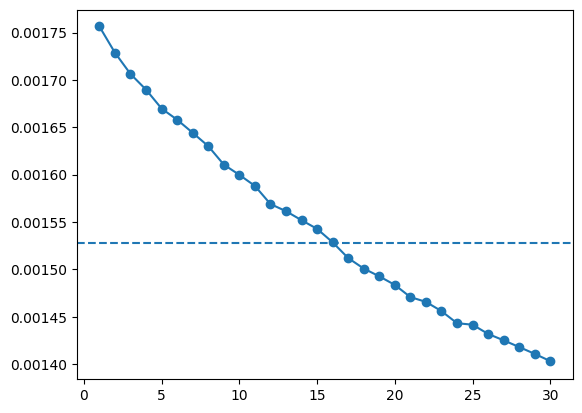

In [7]:
factorization, reconstruction_function = oslo_lib.get_factorization('parafac')
rank_range, errors, error_stds = get_RMSE_error_range(T, factorization, reconstruction_function, k_range, 30, init=init)

threshold = threshold_yen(np.array(errors))
print('thresholding says the elbow is at error = ', threshold)

normalised_errors = [e/max(errors) for e in errors]

plt.errorbar(rank_range, errors, yerr=error_stds, marker='o')
plt.axhline(threshold, ls='--')

/Users/emmanuel/Documents/code/BikePulse/app/CCC.py:65: RuntimeWarning: invalid value encountered in scalar divide
  return num/den


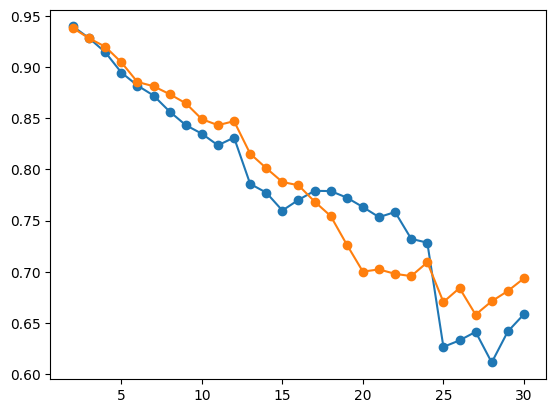

In [8]:
corr_coefs_W = [CCC.compute_rho(k, factorization, T, nruns=1, init=init, use_W=True) for k in k_range]
corr_coefs_H = [CCC.compute_rho(k, factorization, T, nruns=1, init=init, use_W=False) for k in k_range]
plt.plot(k_range, corr_coefs_H, marker='o')
plt.plot(k_range, corr_coefs_W, marker='o')

Text(0, 0.5, 'CCC according to H and W')

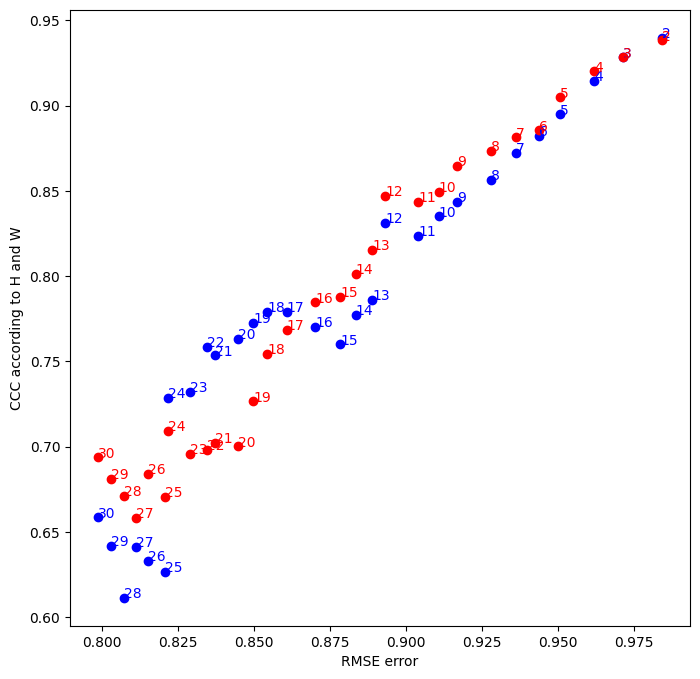

In [9]:
plt.figure(figsize=(8,8))

for c, CC in zip(['b', 'r'], [corr_coefs_H, corr_coefs_W]):
    plt.scatter(normalised_errors, CC, color=c)
    for i, ec in enumerate(zip(normalised_errors, CC)):
        plt.annotate(i+1, ec, color=c)
    
plt.xlabel('RMSE error')
plt.ylabel('CCC according to H and W')

,RMSE,CCC_H,CCC_W,inv_CCC_H,inv_CCC_W,error_L2_H,error_L2_W,error_L2_global
30,0.80,0.66,0.69,0.34,0.31,0.87,0.86,1.22
24,0.82,0.73,0.71,0.27,0.29,0.87,0.87,1.23
29,0.80,0.64,0.68,0.36,0.32,0.88,0.86,1.23
23,0.83,0.73,0.70,0.27,0.30,0.87,0.88,1.24
22,0.83,0.76,0.70,0.24,0.30,0.87,0.89,1.24


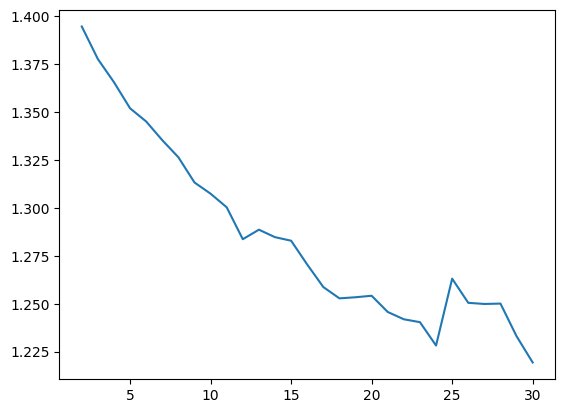

In [10]:
def L2(x):
    return sum([e**2 for e in x])**.5


df_errors = pd.DataFrame({'RMSE':normalised_errors, 'CCC_H':corr_coefs_H, 'CCC_W':corr_coefs_W}, index=k_range)

df_errors['inv_CCC_H'] = 1 - df_errors['CCC_H']
df_errors['inv_CCC_W'] = 1 - df_errors['CCC_W']

df_errors['error_L2_H'] = df_errors[['RMSE', 'inv_CCC_H']].apply(L2, axis=1)
df_errors['error_L2_W'] = df_errors[['RMSE', 'inv_CCC_W']].apply(L2, axis=1)
df_errors['error_L2_global'] = df_errors[['error_L2_H', 'error_L2_W']].apply(L2, axis=1)

# index is the number of clusters.
df_errors.sort_values(by='error_L2_global', inplace=True)
df_errors.sort_index().error_L2_global.plot()
df_errors.round(2).head()

Text(0, 0.5, 'L2 error according to W matrix')

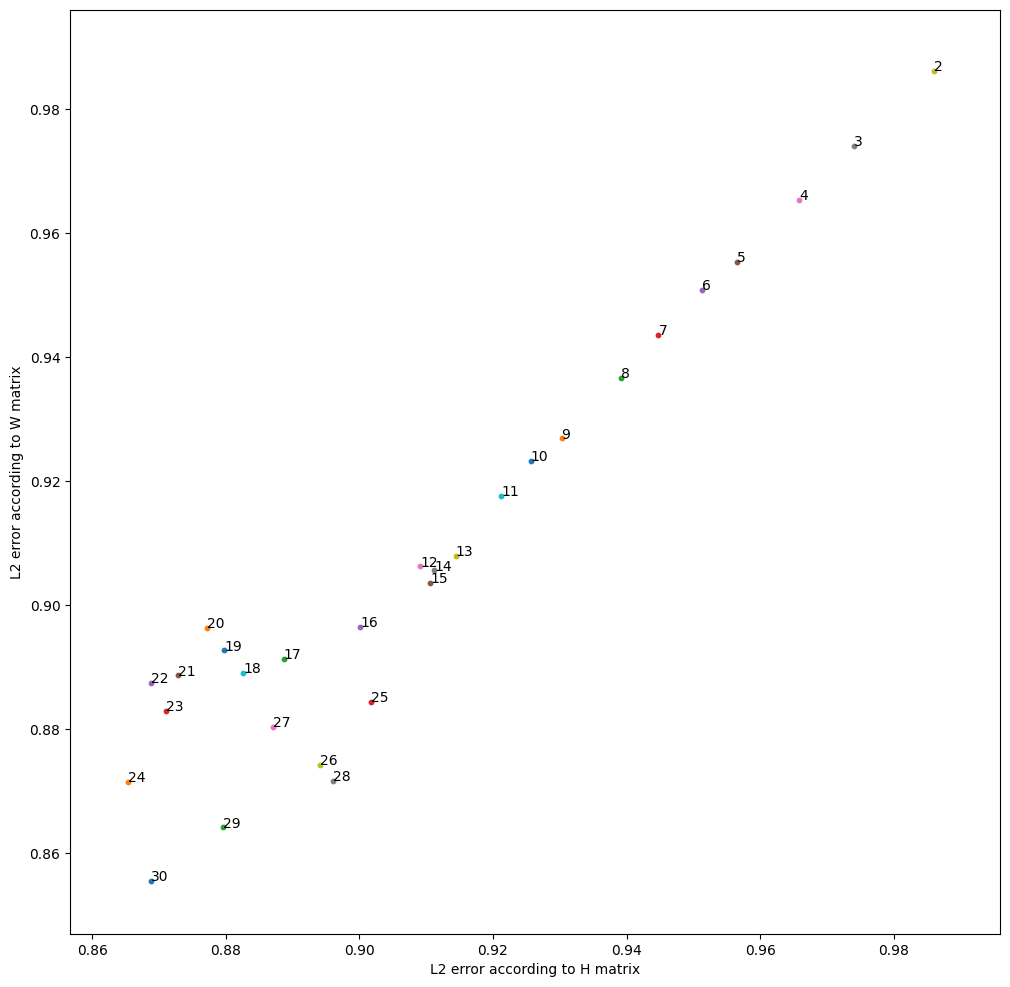

In [11]:
values = [*df_errors[['error_L2_H', 'error_L2_W']].dropna().itertuples()]
#values = values[:20]

fig, ax = plt.subplots(figsize=(12, 12))
for v in values:
    ax.scatter(v[1], v[2], s=10)
    ax.annotate(v[0], v[1:])

ax.set_xlim(.99*min([v[1] for v in values]), max([v[1] for v in values])*1.01)
ax.set_ylim(.99*min([v[2] for v in values]), max([v[2] for v in values])*1.01)

ax.set_xlabel('L2 error according to H matrix')
ax.set_ylabel('L2 error according to W matrix')

In [33]:
n_components = 13

factorization_results = factorization(T, rank=n_components, init='svd')
temporal_factors, W, H = factorization_results.factors
reconstructed_tensor = reconstruction_function(factorization_results)

try:
    core = factorization.core
except AttributeError:
    core = None

trips_in_components = [np.outer(np.outer(w, h), t).sum() for w,h,t in zip(W.T, H.T, temporal_factors.T)]

In [34]:
error = T - reconstructed_tensor

<Axes: >

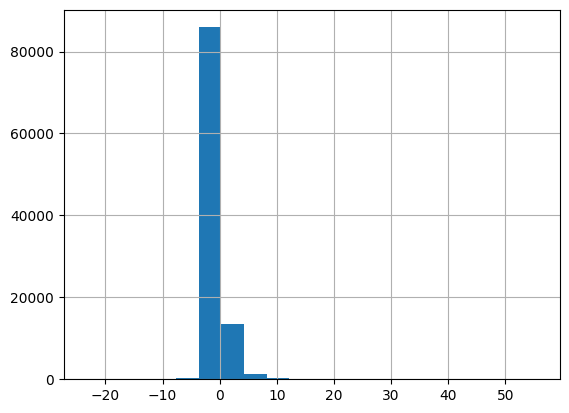

In [35]:
# Relative error
pd.Series((error / T.mean()).flatten()).hist(bins=20)

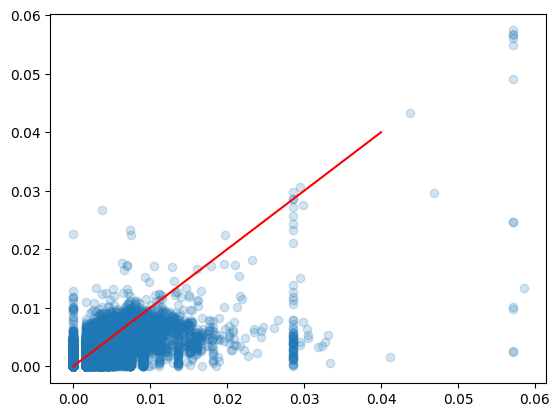

In [36]:
plt.scatter(T.flatten(), reconstructed_tensor.flatten(), alpha=.2)
plt.plot([0,.04], [0, .04], 'r')

In [37]:
cells = time_slices[0].columns

factors = pd.DataFrame()
for n in range(n_components):
    X_ = np.outer(W.T[n], H.T[n])
    factor = pd.DataFrame(X_, 
             index=cells.rename('start_cell'), 
             columns=cells.rename('end_cell'))
    factor = factor.stack().rename('trips').reset_index()
    factor['component'] = n
    factors = pd.concat([factors, factor])

full_factor = factors.groupby(['start_cell', 'end_cell', 'component']).trips.sum().unstack().sum(axis=1).rename('trips').reset_index()
full_factor['component'] = 'full'
factors = pd.concat([factors, full_factor])


In [38]:
factors = factors.join(hex_grid[['geometry']].add_prefix('start_'), on='start_cell')
factors = factors.join(hex_grid[['geometry']].add_prefix('end_'), on='end_cell')
factors = gpd.GeoDataFrame(factors)

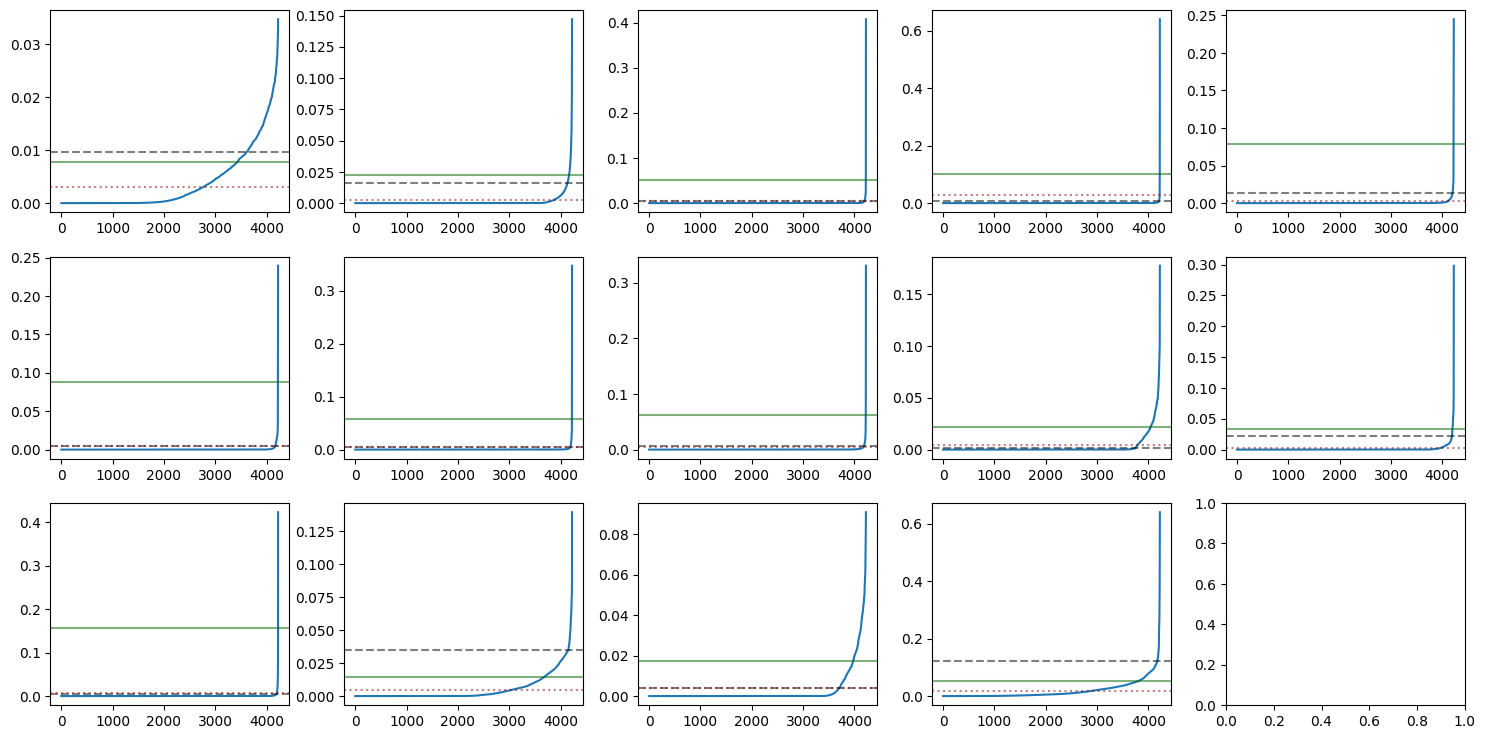

In [39]:
factors_unstacked = factors[['component', 'trips']].reset_index().pivot_table(index='index', columns='component', values='trips')

n_col = int(np.sqrt(len(factors_unstacked.columns)))
n_rows = int(np.ceil(len(factors_unstacked.columns)/n_col))
fig, axes = plt.subplots(n_col, n_rows, figsize=(5 * n_col,1.5*n_rows))
axes=axes.flatten()

for e, ax in zip(factors_unstacked.values.T, axes):
    ax.plot(sorted(e))
    ax.axhline(threshold_otsu(e), ls='-', color='darkgreen', alpha=.5)
    ax.axhline(threshold_yen(e), ls='--', color='k', alpha=.5)
    ax.axhline(threshold_li(e), ls=':', color='darkred', alpha=.5)

plt.tight_layout()

In [40]:
top_trips =  None # takes precedence
q_thresh = .99
threshold_function = threshold_yen

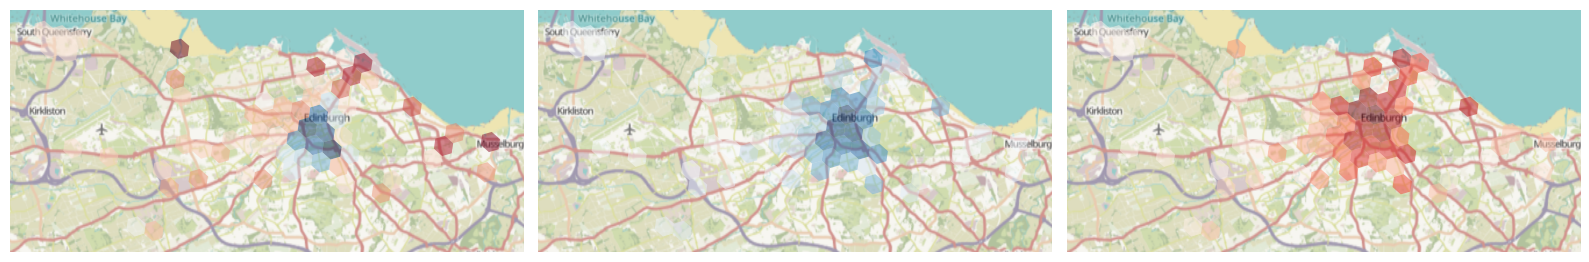

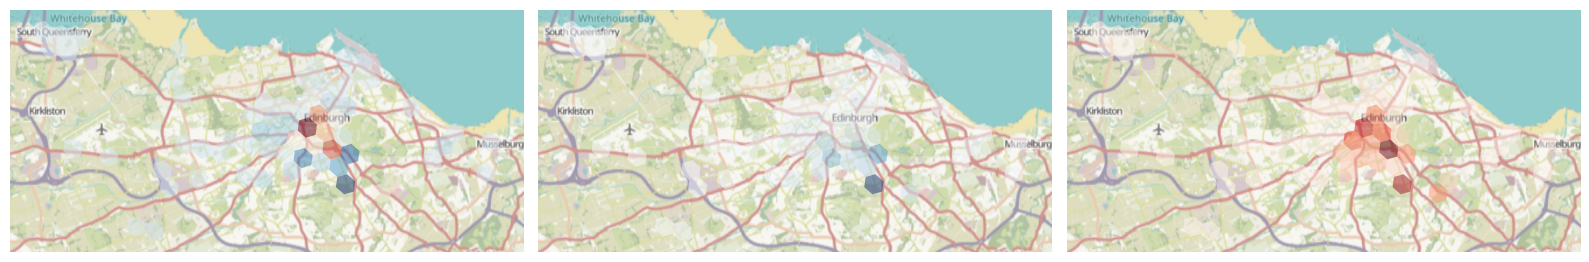

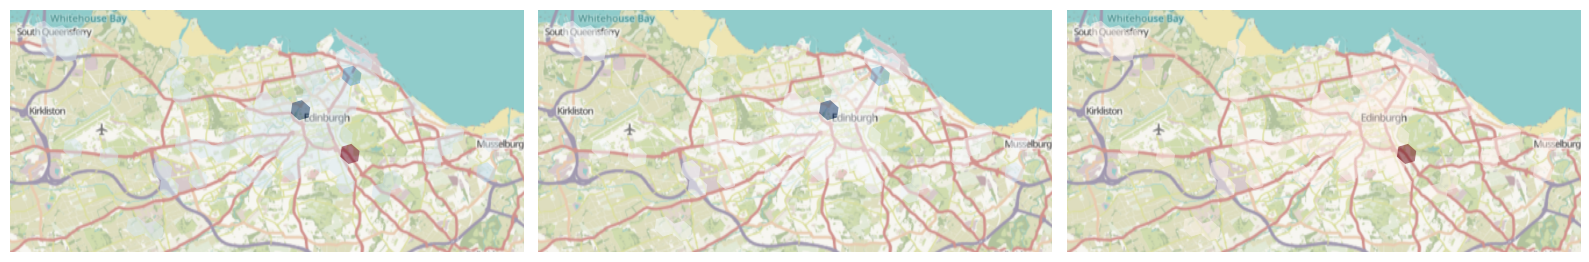

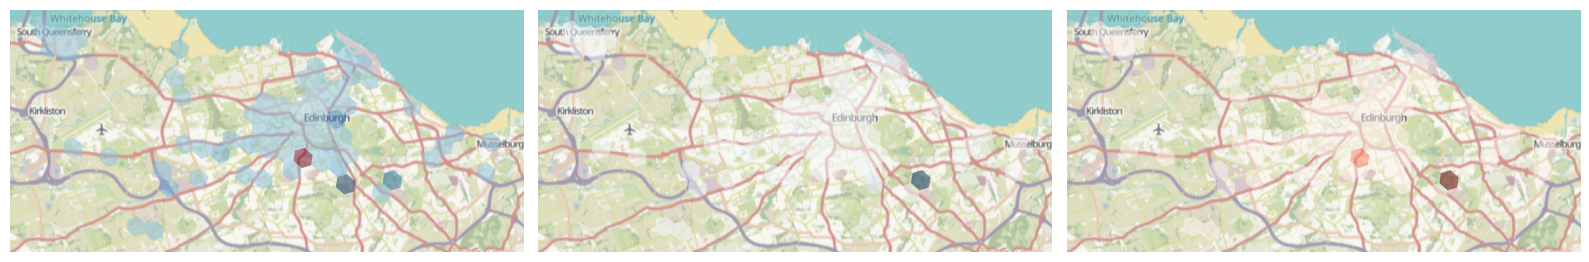

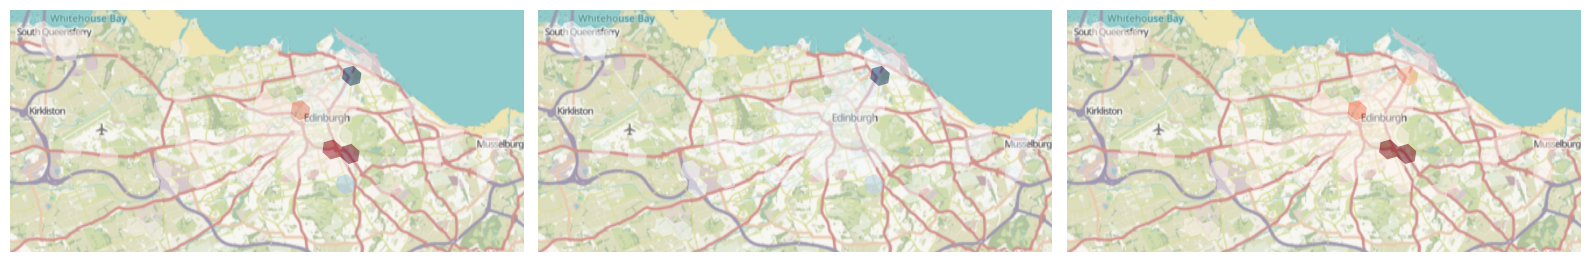

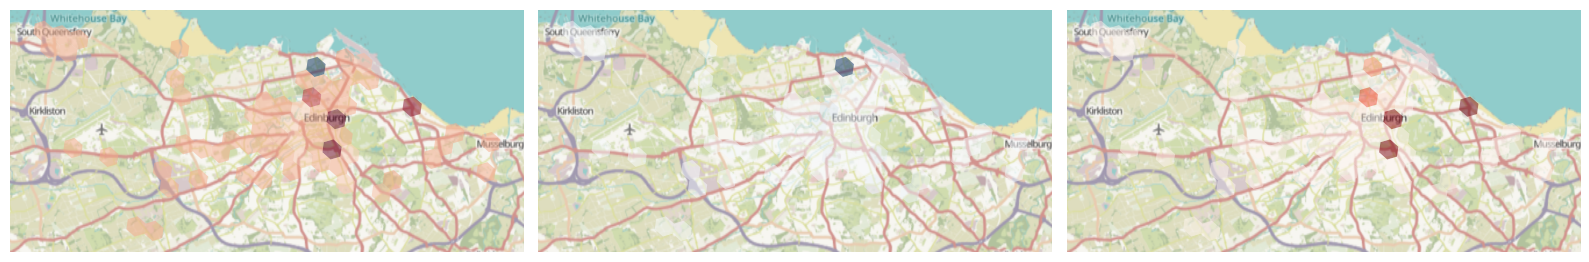

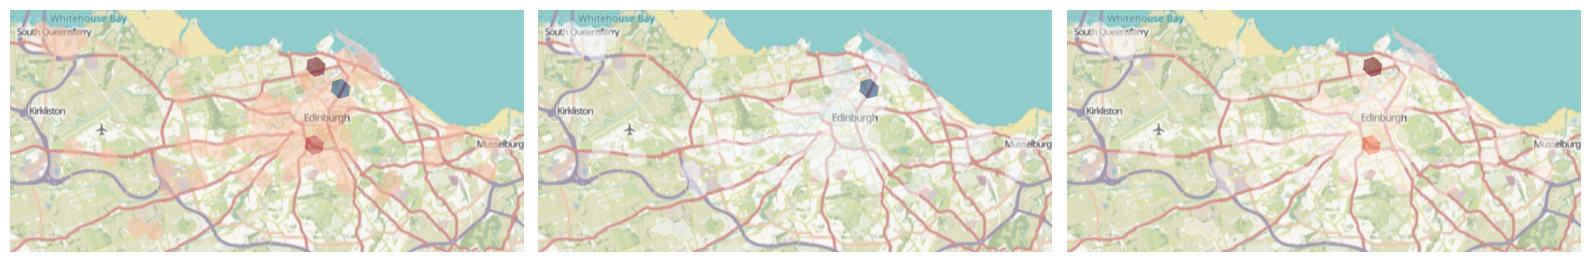

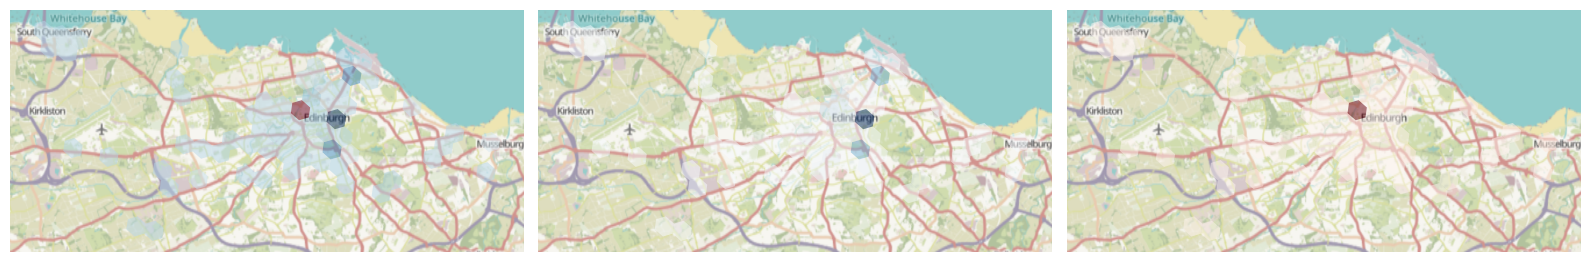

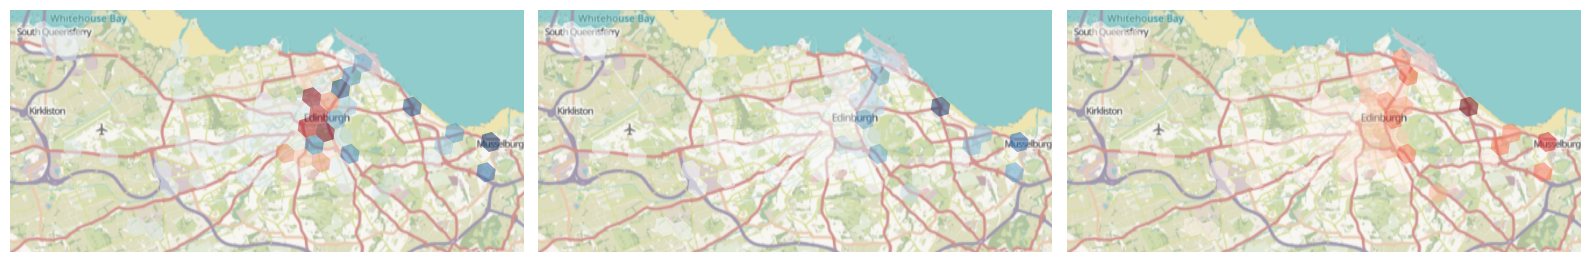

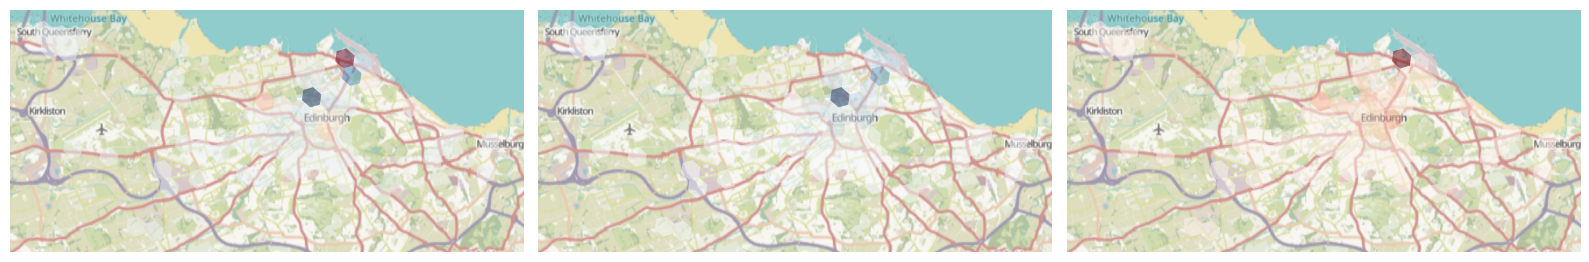

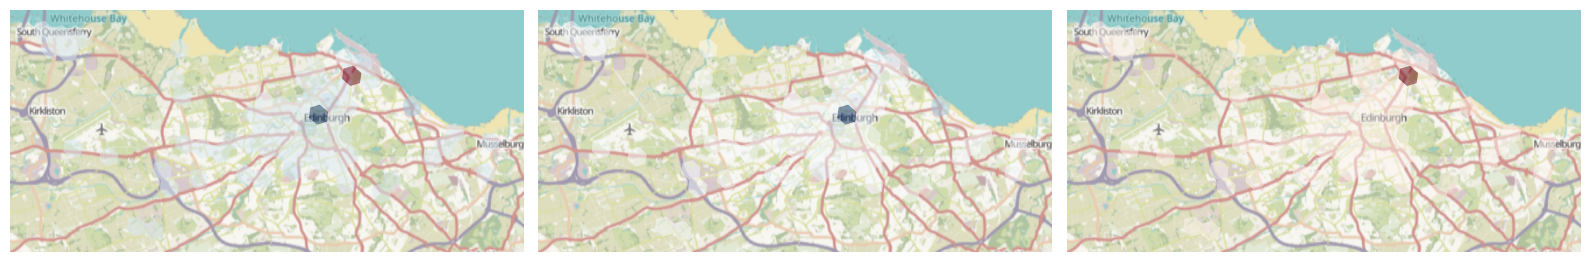

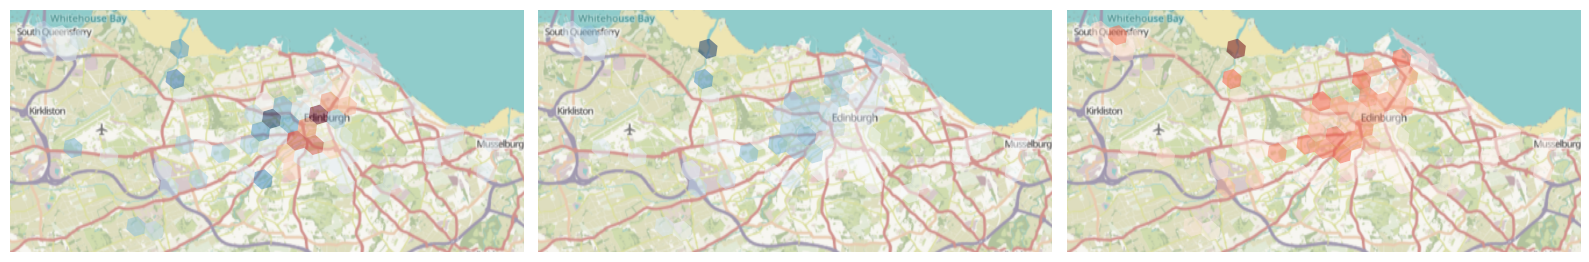

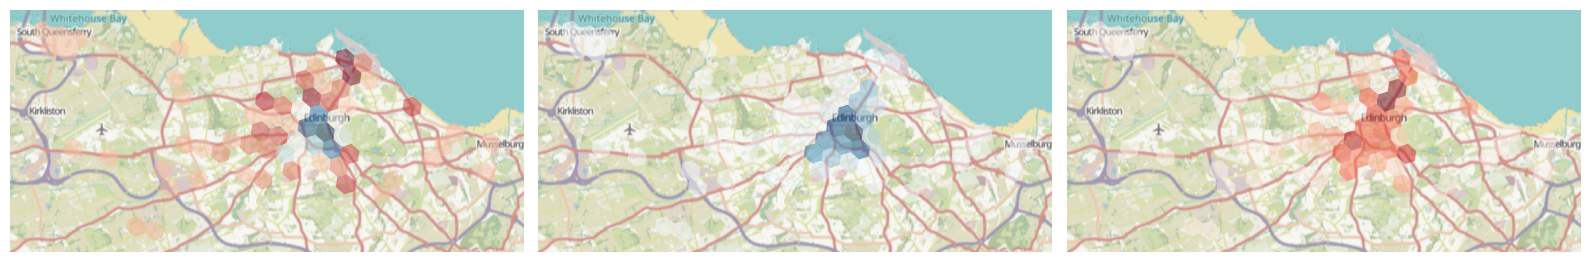

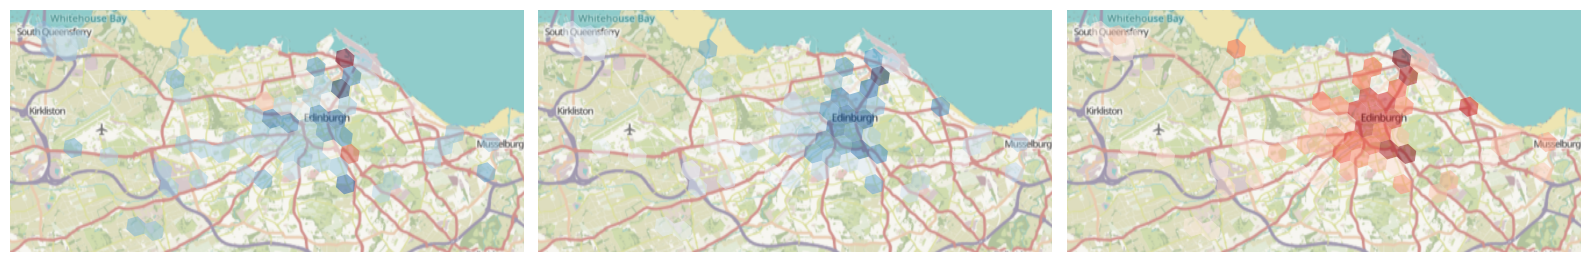

In [42]:
for component, factor in factors.groupby("component"):
    factor = pd.concat([factor.groupby("start_cell")['trips'].sum().rename("departures"), factor.groupby("end_cell")['trips'].sum().rename("arrivals"), hex_grid['geometry']], axis=1).dropna()
    factor = gpd.GeoDataFrame(factor, crs=hex_grid.crs)
    factor['net_flow'] = factor['arrivals'] - factor['departures']

    fig, axes = plt.subplots(1, 3, figsize=(16,6))

    factor.plot(column='net_flow', cmap="RdBu_r", alpha=.5, ax=axes[0])
    factor.plot(column='departures', cmap="Blues", alpha=.5, ax=axes[1])
    factor.plot(column='arrivals', cmap="Reds", alpha=.5, ax=axes[2])

    for ax in axes:
        ctx.add_basemap(ax=ax, crs=hex_grid.crs, attribution='')
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [43]:
from itertools import cycle

def cycle_colors(colors = ['Blue', 'Green', 'Purple', 'Orange', 'Red', 'Yellow', 'Grey'], make_cmaps=False):
    if make_cmaps:
        yield from cycle([c+'s' for c in colors if c!='Yellow'])
    else:
        yield from cycle(colors)

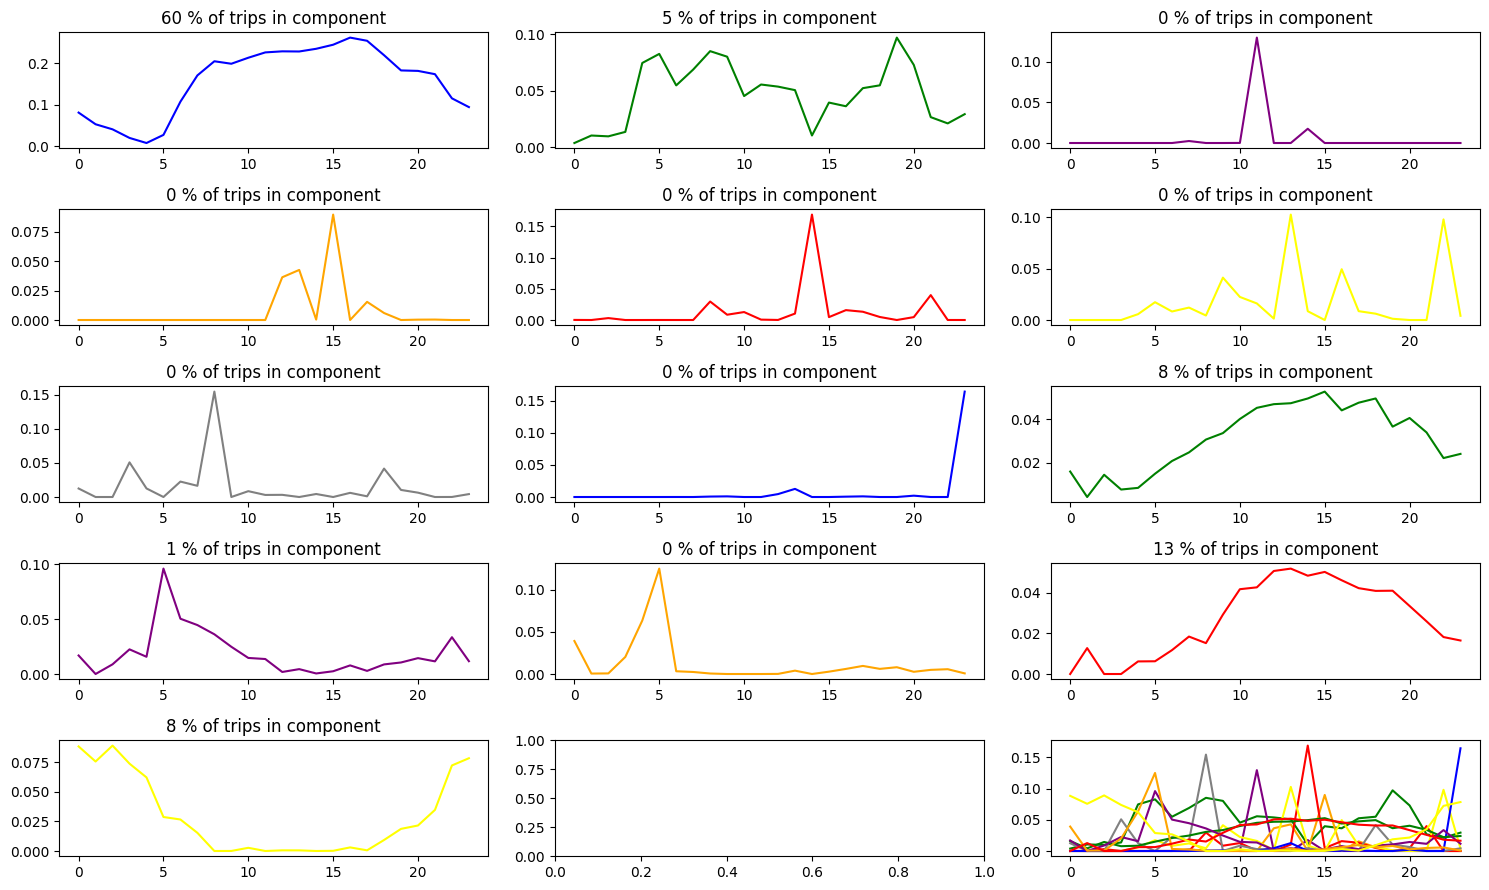

In [44]:
n_rows = int(np.ceil(np.sqrt(len(temporal_factors.T))))+1
n_cols = int(np.ceil(len(temporal_factors.T)/n_rows))
if n_rows * n_cols == len(temporal_factors.T):
    n_rows+=1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_col,1.8*n_rows))

axes = axes.flatten()
ct = 0
for ax, t, n_trips, color in zip(axes, temporal_factors.T, trips_in_components, cycle_colors()):
    ax.plot(t, c=color)
    ax.set_title(f'{int(n_trips)} % of trips in component')
    if ct!=0:
        axes[-1].plot(t, c=color)
    ct+=1

plt.tight_layout()